In [ ]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

Mounted at /content/drive


--- D1: T-test (AOV Impact) ---
P-value: 0.1716 (Not Significant)

--- LASSO REGRESSION RESULTS ---
        Feature  Coefficient
1     Frequency     0.222712
2      Monetary    -0.000000
3  Coupon_Ratio    -0.000000
0       Recency    -0.055480


/tmp/ipykernel_11243/2535578777.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=rfm, palette='viridis')



[DONE] File 'Final_Phase2_Analysis_Report.csv' and images have been generated.


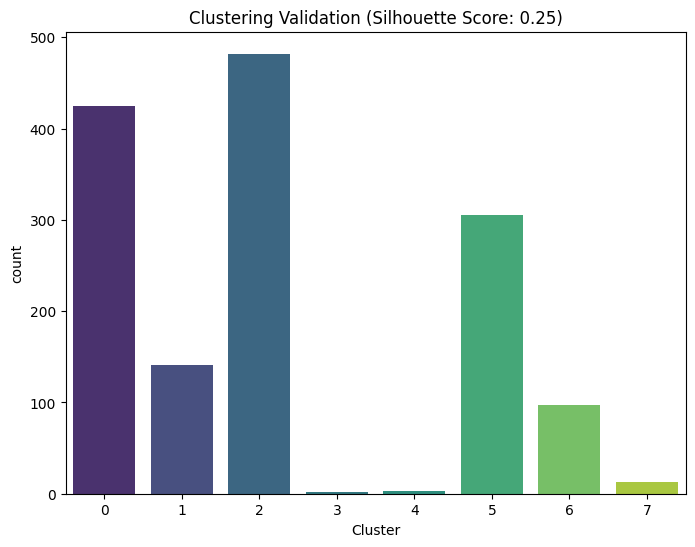

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import silhouette_samples, silhouette_score, roc_auc_score
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD & PREPARE DATA
# ==========================================
df = pd.read_csv("/content/drive/MyDrive/PTTK/Clean_Online_Sales_with_VIP_type.csv")
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

# Calculate RFM-C (Recency, Frequency, Monetary, Coupon_Ratio)
ref_date = df['Transaction_Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (ref_date - x.max()).days,
    'Transaction_ID': 'nunique',
    'Transaction_Value': 'sum',
    'Coupon_Status': lambda x: (x == 'Used').mean()
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Coupon_Ratio']

# ==========================================
# 2. INFERENTIAL STATISTICS (D1 & D2)
# ==========================================
print("--- D1: T-test (AOV Impact) ---")
group_used = df[df['Coupon_Status'] == 'Used']['Transaction_Value']
group_not_used = df[df['Coupon_Status'] == 'Not Used']['Transaction_Value']
t_stat, p_val = stats.ttest_ind(group_used, group_not_used)
print(f"P-value: {p_val:.4f} ({'Significant' if p_val < 0.05 else 'Not Significant'})\n")

# ==========================================
# 3. CUSTOMER SEGMENTATION (DP-MEANS)
# ==========================================
# Scaling data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary', 'Coupon_Ratio']])

# DP-means (Non-parametric)
def dp_means(X, lambd=15.0, max_iter=50):
    centers = [np.mean(X, axis=0)]
    assignments = np.zeros(X.shape[0], dtype=int)
    for _ in range(max_iter):
        changed = False
        for j in range(X.shape[0]):
            distances = [np.sum((X[j] - c)**2) for c in centers]
            min_dist = min(distances)
            if min_dist > lambd:
                centers.append(X[j])
                assignments[j] = len(centers) - 1
                changed = True
            else:
                new_assign = np.argmin(distances)
                if assignments[j] != new_assign:
                    assignments[j] = new_assign
                    changed = True
        new_centers = [np.mean(X[assignments == k], axis=0) for k in range(len(centers))]
        centers = new_centers
        if not changed: break
    return np.array(centers), assignments

# clutering 8 cluters
centers, clusters = dp_means(X_scaled, lambd=15.0)
rfm['Cluster'] = clusters

# Group into 5 strategic segments
def mapping_segments(row):
    if row['Cluster'] in [3, 4]: return "Champions (VIPs)"
    if row['Cluster'] in [6, 7]: return "Loyalists"
    if row['Cluster'] == 1:      return "Deal Seekers"
    if row['Cluster'] in [2, 5]: return "Potential Growth"
    return "At Risk / Hibernating"

rfm['Segment'] = rfm.apply(mapping_segments, axis=1)

# ==========================================
# 4. BASELINE MODEL (LASSO REGRESSION)
# ==========================================
# Create a Target: 1 if it belongs to the High-Value group (high purchase frequency), 0 otherwise.
y = (rfm['Frequency'] > rfm['Frequency'].median()).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Training Lasso for Feature Selection
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

# Print the Lasso weighting results
lasso_coefs = pd.DataFrame({
    'Feature': ['Recency', 'Frequency', 'Monetary', 'Coupon_Ratio'],
    'Coefficient': lasso.coef_
}).sort_values(by='Coefficient', ascending=False)

print("--- LASSO REGRESSION RESULTS ---")
print(lasso_coefs)

# ==========================================
# 5. OUTPUT & VISUALIZATION
# ==========================================
# Save the resulting file
rfm.to_csv("Final_Phase2_Analysis_Report.csv", index=False)

# Draw a Silhouette chart for Validation
plt.figure(figsize=(8, 6))
score = silhouette_score(X_scaled, clusters)
plt.title(f"Clustering Validation (Silhouette Score: {score:.2f})")
sns.countplot(x='Cluster', data=rfm, palette='viridis')
plt.savefig("segmentation_summary.png")

print("\n[DONE] File 'Final_Phase2_Analysis_Report.csv' and images have been generated.")